## Model 2 Implementation (Inspired by Meso 4 Model)

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
print(os.path.exists('/content/drive/Shareddrives/cmpe 257 Team 7/Project Code/cropped_images'))


True


In [ ]:
import os
import json
import numpy as np
import cv2
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, accuracy_score
import matplotlib.pyplot as plt

IMAGE_DIR = '/content/drive/Shareddrives/cmpe 257 Team 7/Project Code/cropped_images'
METADATA_PATH = '/content/drive/Shareddrives/cmpe 257 Team 7/Project Code/deepfake-detection-challenge/train_sample_videos/metadata.json'

# load metadata and preprocess filenames to strip `.mp4` for easier matching
with open(METADATA_PATH, 'r') as f:
    metadata = json.load(f)

processed_metadata = {key.split('.')[0]: metadata[key] for key in metadata}

print("Metadata keys sample (processed):")
for key in list(processed_metadata.keys())[:10]:
    print(key, "->", processed_metadata[key])

def load_data(image_dir, metadata):
    images = []
    labels = []
    unmatched_ids = set()

    found_count = 0
    not_found_count = 0

    for image_name in os.listdir(image_dir):
        if image_name.endswith('.jpg'):
            # now we remove the file type suffix of '_number.jpg' so we can only have the file name
            base_name = image_name.split('_')[0]

            # check if the file name (base_name) exists in the processed metadata
            if base_name in metadata:
                # retriving the the label from metadata
                label = 1 if metadata[base_name]['label'] == 'FAKE' else 0
                image_path = os.path.join(image_dir, image_name)
                image = cv2.imread(image_path)

                if image is not None:
                    # resizing and normalizing image for consistency
                    image = cv2.resize(image, (224, 224))  # 24x224 pixels
                    image = image / 255.0  # normalize pixel values to [0, 1]
                    images.append(image)
                    labels.append(label)
                    found_count += 1
                else:
                    print(f"Failed to load image: {image_name}")
            else:
                unmatched_ids.add(base_name)
                not_found_count += 1

    # debug
    print(f"Total images processed: {found_count + not_found_count}")
    print(f"Matched: {found_count}, Unmatched: {not_found_count}")
    if unmatched_ids:
        print(f"Unmatched base names: {list(unmatched_ids)[:10]}")  # Debug info
        with open('unmatched_ids.txt', 'w') as f:
            f.write('\n'.join(unmatched_ids))

    return np.array(images), np.array(labels)


# load dataset and checking how many images we were able to process and label
images, labels = load_data(IMAGE_DIR, processed_metadata)

print(f"Number of images loaded: {len(images)}")
print(f"Number of labels loaded: {len(labels)}")
print(f"Shape of image array: {images.shape}")
print(f"Shape of label array: {labels.shape}")


Metadata keys sample (processed):
aagfhgtpmv -> {'label': 'FAKE', 'split': 'train', 'original': 'vudstovrck.mp4'}
aapnvogymq -> {'label': 'FAKE', 'split': 'train', 'original': 'jdubbvfswz.mp4'}
abarnvbtwb -> {'label': 'REAL', 'split': 'train', 'original': None}
abofeumbvv -> {'label': 'FAKE', 'split': 'train', 'original': 'atvmxvwyns.mp4'}
abqwwspghj -> {'label': 'FAKE', 'split': 'train', 'original': 'qzimuostzz.mp4'}
acifjvzvpm -> {'label': 'FAKE', 'split': 'train', 'original': 'kbvibjhfzo.mp4'}
acqfdwsrhi -> {'label': 'FAKE', 'split': 'train', 'original': 'ccfoszqabv.mp4'}
acxnxvbsxk -> {'label': 'FAKE', 'split': 'train', 'original': 'fjlyaizcwc.mp4'}
acxwigylke -> {'label': 'FAKE', 'split': 'train', 'original': 'ffcwhpnpuw.mp4'}
aczrgyricp -> {'label': 'FAKE', 'split': 'train', 'original': 'slwkmefgde.mp4'}
Total images processed: 2609
Matched: 2517, Unmatched: 92
Unmatched base names: ['cprhtltsj', 'curpwogll', 'aladcziid', 'aczrgyric']
Number of images loaded: 2517
Number of label

In [ ]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.2, random_state=42)


In [ ]:
# data Augmentation


data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1),
])

In [ ]:


def team7_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(8, (3, 3), padding='same', input_shape=(224, 224, 3), kernel_regularizer=tf.keras.regularizers.L2(0.01)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        tf.keras.layers.Conv2D(16, (3, 3), padding='same', kernel_regularizer=tf.keras.regularizers.L2(0.01)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        tf.keras.layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer=tf.keras.regularizers.L2(0.01)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        tf.keras.layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=tf.keras.regularizers.L2(0.01)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.L2(0.01)),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1)
    ])
    return model


model = team7_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), #try to update learning rate per epoch (might help with overfitting)
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),  # updated loss
    metrics=[tf.keras.metrics.BinaryAccuracy(threshold=0.5)]
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

# predictions
y_pred_prob = tf.sigmoid(model.predict(X_test).ravel()).numpy()
y_pred = (y_pred_prob > 0.5).astype(int)

# accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - binary_accuracy: 0.6197 - loss: 9.7239 - val_binary_accuracy: 0.2947 - val_loss: 4.0353
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - binary_accuracy: 0.7197 - loss: 3.4965 - val_binary_accuracy: 0.7053 - val_loss: 2.6334
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - binary_accuracy: 0.7751 - loss: 2.2844 - val_binary_accuracy: 0.7053 - val_loss: 1.9379
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - binary_accuracy: 0.7986 - loss: 1.6522 - val_binary_accuracy: 0.7053 - val_loss: 1.5527
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - binary_accuracy: 0.8497 - loss: 1.2306 - val_binary_accuracy: 0.7053 - val_loss: 1.3204
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - binary_accuracy: 0.8172 - loss: 1.0497 - val_binary_accuracy: 0.7053 - val_loss: 1.1786
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - binary_accuracy: 0.8530 - loss: 0.8411 - val_binary_accuracy: 0.7053 - val_loss: 1.2509
Epoch 8/20
50/50

Precision: 0.82
Recall: 1.00
F1 Score: 0.90


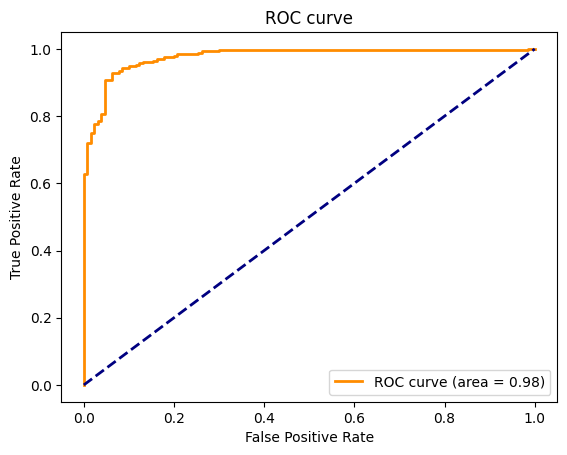

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# compute precision, recall, and f1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')


# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve')
plt.legend(loc='lower right')
plt.show()




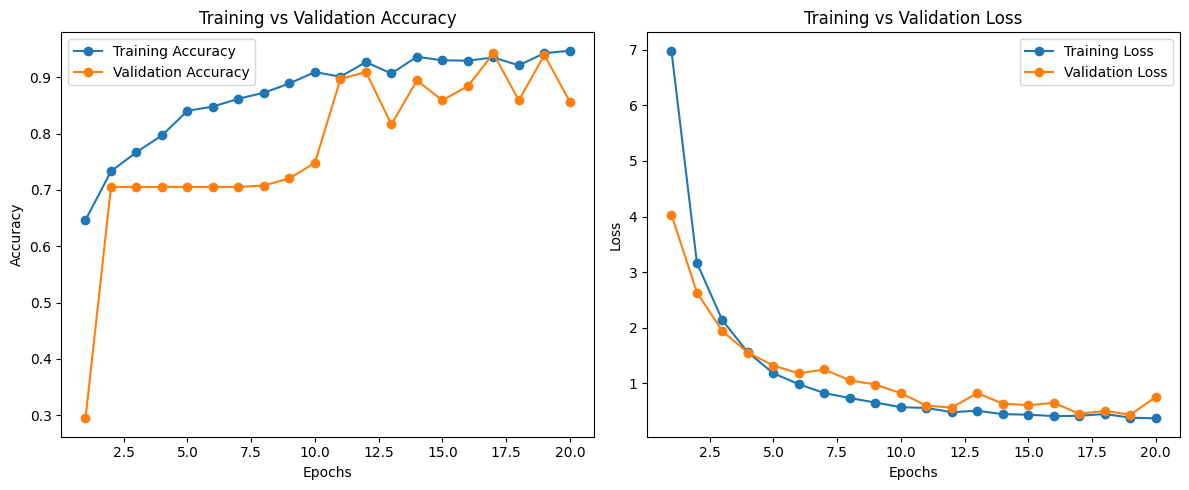

In [ ]:
def plot_training_history(history):

    acc = history.history['binary_accuracy']
    val_acc = history.history['val_binary_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    # plotting model accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy', marker='o')
    plt.plot(epochs, val_acc, label='Validation Accuracy', marker='o')
    plt.title('Training vs Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # plot model loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss', marker='o')
    plt.plot(epochs, val_loss, label='Validation Loss', marker='o')
    plt.title('Training vs Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()


plot_training_history(history)
